<a href="https://colab.research.google.com/github/Sherlysukmadira/2311532015_Sherly-Sukmadira-Putri_ImageProcessing/blob/main/Fake%20or%20Real%20News%20Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORT LIBRARIES**

In [ ]:
import pandas as pd

# **PENGECEKAN DATASET**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/news.csv')
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [ ]:
df.shape

(6335, 4)

# **PREPROCESSING**

In [ ]:
missing_values = df.isnull().sum()
print("Missing value pada dataset:\n")
missing_values

Missing value pada dataset:



,0
Unnamed: 0,0
title,0
text,0
label,0


In [ ]:
df = df.drop('Unnamed: 0', axis=1)
df

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...
6330,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6335 entries, 0 to 6334
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   6335 non-null   object
 1   text    6335 non-null   object
 2   label   6335 non-null   object
dtypes: object(3)
memory usage: 148.6+ KB


In [ ]:
df.shape

(6335, 3)

In [ ]:
df.isnull().sum()

,0
title,0
text,0
label,0


In [ ]:
pd.set_option('display.max_colwidth', None)
df.head(10)

title  \
0                                                           You Can Smell Hillary’s Fear   
1  Watch The Exact Moment Paul Ryan Committed Political Suicide At A Trump Rally (VIDEO)   
2                                            Kerry to go to Paris in gesture of sympathy   
3   Bernie supporters on Twitter erupt in anger against the DNC: 'We tried to warn you!'   
4                                       The Battle of New York: Why This Primary Matters   
5                                                                            Tehran, USA   
6              Girl Horrified At What She Watches Boyfriend Do After He Left FaceTime On   
7                                                      ‘Britain’s Schindler’ Dies at 106   
8                        Fact check: Trump and Clinton at the 'commander-in-chief' forum   
9                Iran reportedly makes new push for uranium concessions in nuclear talks   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [ ]:
label_counts = df['label'].value_counts()
print(label_counts)

total_count = len(df)
percentages = (label_counts / total_count) * 100

print("\nPersentase banyak tiap label:")
for label, percentage in percentages.items():
    print(f"{label}: {percentage:.2f}%")

label
REAL    3171
FAKE    3164
Name: count, dtype: int64

Persentase banyak tiap label:
REAL: 50.06%
FAKE: 49.94%


In [ ]:
pip install nltk


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import re
import string
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    if not isinstance(text, str):
        return ""

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # remove mentions & hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # remove punctuation except numbers and letters
    # keep angka, huruf, dan spasi
    text = re.sub(r'[^a-z0-9\s]', ' ', text)

    # remove emojis
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(r'', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
def tokenize_and_lemmatize(text):
    # tokenization
    tokens = nltk.word_tokenize(text)

    # remove stopwords + lemmatize
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

In [ ]:
df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")

In [ ]:
df["clean"] = df["content"].apply(clean_text)
df["processed_data"] = df["clean"].apply(tokenize_and_lemmatize)

In [ ]:
print("Dataset setelah dibersihkan:")
print(df[["processed_data", "label"]].head())

Dataset setelah dibersihkan:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           

In [ ]:
df.to_csv('news_processed.csv', index=False)
print('Dataset bersih tersimpan ke file: news_processed.csv')

Dataset bersih tersimpan ke file: news_processed.csv


# **Training Data**

In [ ]:
X = df["processed_data"]
y = df["label"]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# **Feature Engineering + Modelling**

**TF-IDF + Logistic Regression**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, precision_score, accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)  # Fit on training data
y_test = le.transform(y_test)      # Transform test data

In [ ]:
# TF-IDF Vectorization (fit on training data, transform both)
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

print(f"TF-IDF matrix shape: {X_train.shape}")

TF-IDF matrix shape: (5068, 53338)


In [ ]:
from sklearn.linear_model import LogisticRegression
tfidf_lr_model = LogisticRegression()
tfidf_lr_model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
X_train_prediction = tfidf_lr_model.predict(X_train)
X_test_prediction = tfidf_lr_model.predict(X_test)
y_pred_proba = tfidf_lr_model.predict_proba(X_test)[:, 1]

train_accuracy = accuracy_score(y_train, X_train_prediction)
test_accuracy = accuracy_score(y_test, X_test_prediction)

print(f'Training Data Accuracy: {train_accuracy:.4f}')
print(f'Test Data Accuracy: {test_accuracy:.4f}')

Training Data Accuracy: 0.9536
Test Data Accuracy: 0.9242


In [ ]:
import numpy as np

In [ ]:
# Misclassifications
total_test_samples = len(y_test)
misclassified_samples = np.sum(y_test != X_test_prediction)
print(f'Total test samples: {total_test_samples}')
print(f'Total misclassified samples: {misclassified_samples}')
print(f'Misclassification rate: {(misclassified_samples / total_test_samples) * 100:.2f}%')

Total test samples: 1267
Total misclassified samples: 96
Misclassification rate: 7.58%


In [ ]:
true_fake_predicted_real = np.sum((y_test == 0) & (X_test_prediction == 1))
true_real_predicted_fake = np.sum((y_test == 1) & (X_test_prediction == 0))
print(f'Breakdown of misclassifications:')
print(f'True Fake predicted as Real (False Positive): {true_fake_predicted_real}')
print(f'True Real predicted as Fake (False Negative): {true_real_predicted_fake}')

Breakdown of misclassifications:
True Fake predicted as Real (False Positive): 28
True Real predicted as Fake (False Negative): 68


In [ ]:
print(f"Overall Accuracy: {test_accuracy:.4f}")
print('Classification Report:')
print(classification_report(y_test, X_test_prediction, target_names=['FAKE', 'REAL']))

Overall Accuracy: 0.9242
Classification Report:
              precision    recall  f1-score   support

        FAKE       0.90      0.96      0.93       633
        REAL       0.95      0.89      0.92       634

    accuracy                           0.92      1267
   macro avg       0.93      0.92      0.92      1267
weighted avg       0.93      0.92      0.92      1267



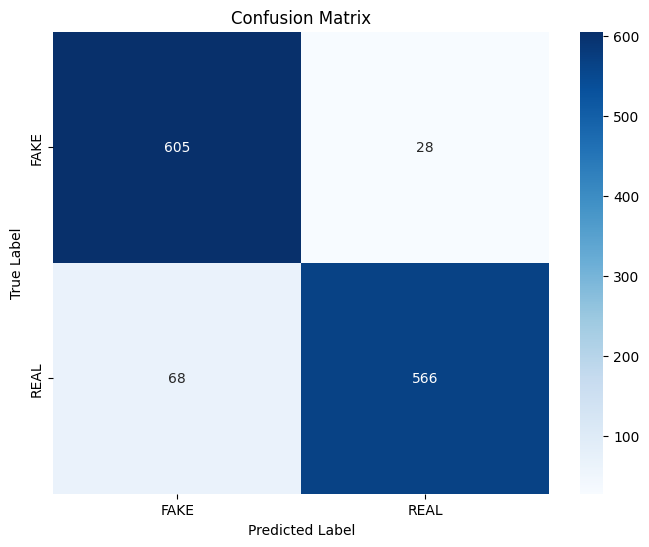

Cross-validation scores: [0.90828402 0.90039448 0.91321499 0.89930898 0.90819348]
Average CV Score: 0.9059 (+/- 0.0105)


In [ ]:
cm = confusion_matrix(y_test, X_test_prediction)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['FAKE', 'REAL'], yticklabels=['FAKE', 'REAL'])
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

cv_scores = cross_val_score(tfidf_lr_model, X_train, y_train, cv=5)
print('Cross-validation scores:', cv_scores)
print(f'Average CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})')  # Standar Deviasi

Feature names: 53338
Model coefficients: 53338


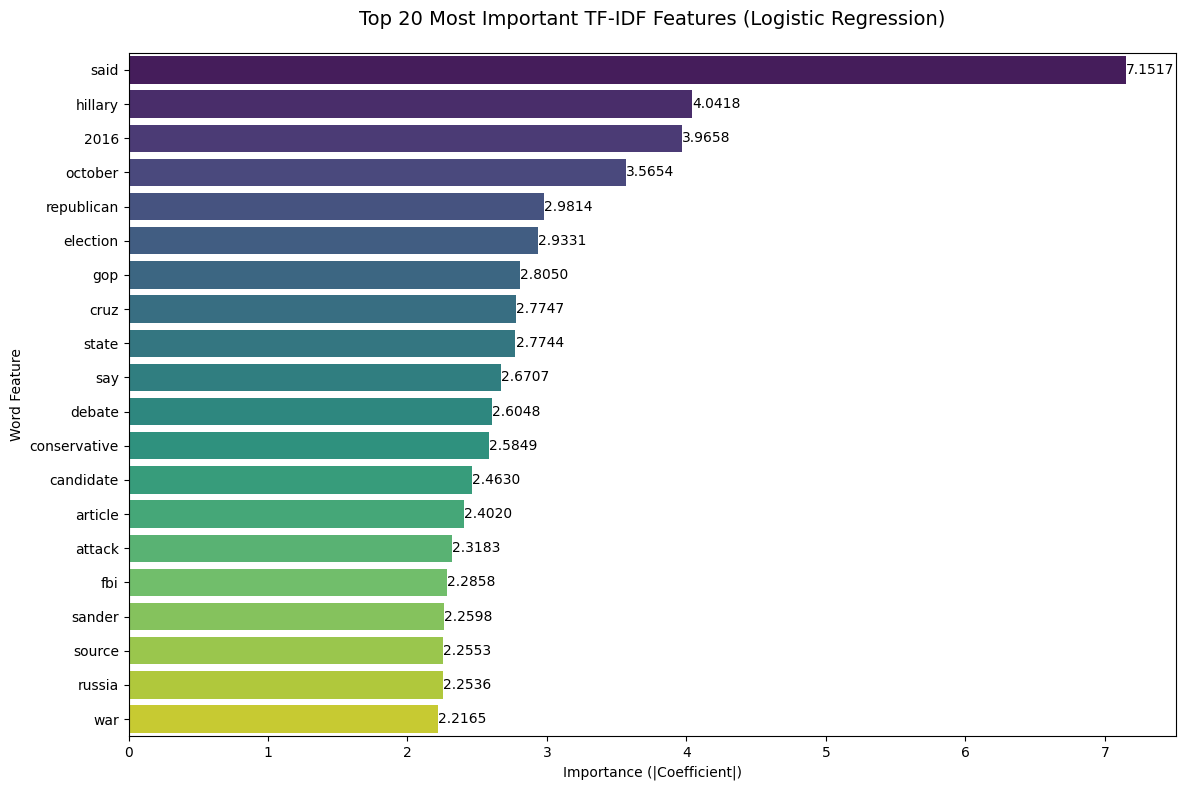


Top Feature Importance:
said                 7.1517
hillary              4.0418
2016                 3.9658
october              3.5654
republican           2.9814
election             2.9331
gop                  2.8050
cruz                 2.7747
state                2.7744
say                  2.6707
debate               2.6048
conservative         2.5849
candidate            2.4630
article              2.4020
attack               2.3183
fbi                  2.2858
sander               2.2598
source               2.2553
russia               2.2536
war                  2.2165


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Ambil nama feature dari TF-IDF
feature_names = vectorizer.get_feature_names_out()

# Ambil koefisien Logistic Regression dari model TF-IDF yang baru
coeffs = tfidf_lr_model.coef_[0]

# Pastikan panjang sama (harusnya sama karena vectorizer fit pada train)
print("Feature names:", len(feature_names))
print("Model coefficients:", len(coeffs))

# Buat dataframe rank feature importance
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': np.abs(coeffs)
}).sort_values('importance', ascending=False)

top_features = feature_importance.head(20)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    x='importance',
    y='feature',
    data=top_features,
    hue='feature',
    palette='viridis',
    legend=False
)

for i, v in enumerate(top_features['importance']):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=10)

plt.title('Top 20 Most Important TF-IDF Features (Logistic Regression)', fontsize=14, pad=20)
plt.xlabel('Importance (|Coefficient|)')
plt.ylabel('Word Feature')
plt.tight_layout()
plt.show()

print("\nTop Feature Importance:")
for feature, importance in zip(top_features['feature'], top_features['importance']):
    print(f"{feature:<20} {importance:.4f}")

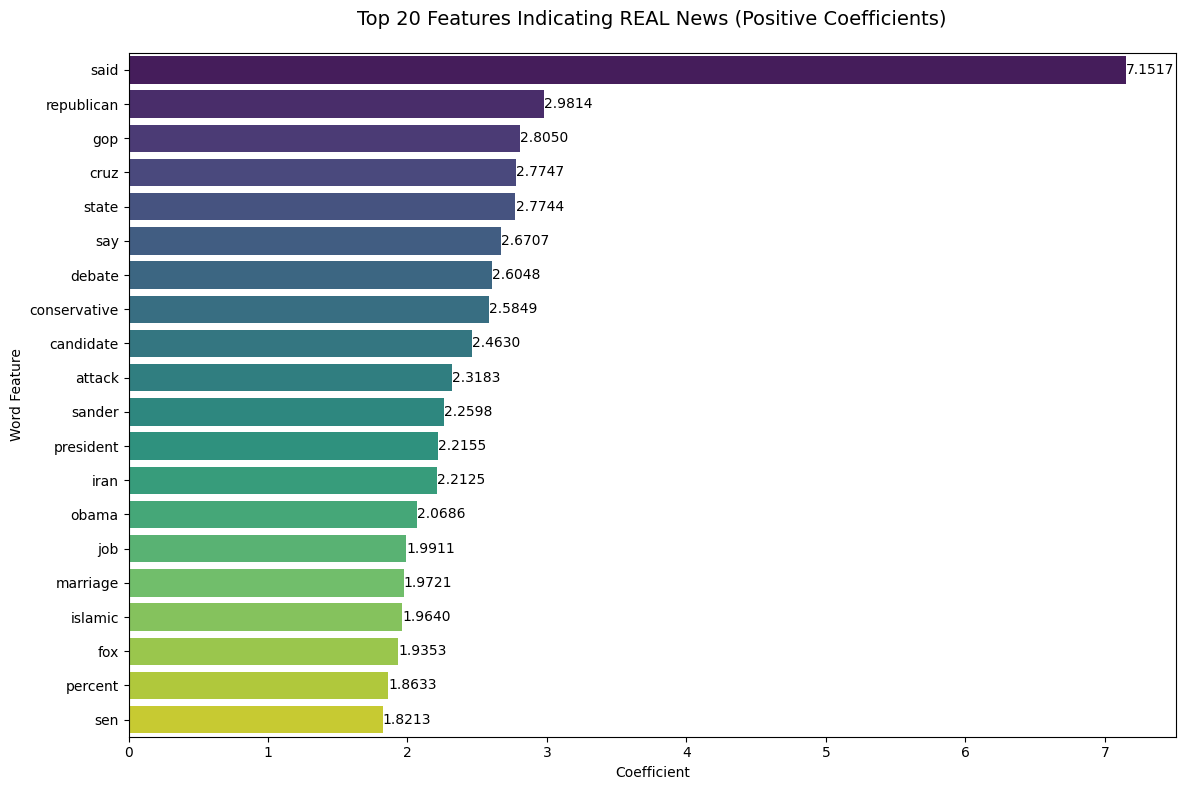


Top 20 Features for REAL News:
said                 7.1517
republican           2.9814
gop                  2.8050
cruz                 2.7747
state                2.7744
say                  2.6707
debate               2.6048
conservative         2.5849
candidate            2.4630
attack               2.3183
sander               2.2598
president            2.2155
iran                 2.2125
obama                2.0686
job                  1.9911
marriage             1.9721
islamic              1.9640
fox                  1.9353
percent              1.8633
sen                  1.8213


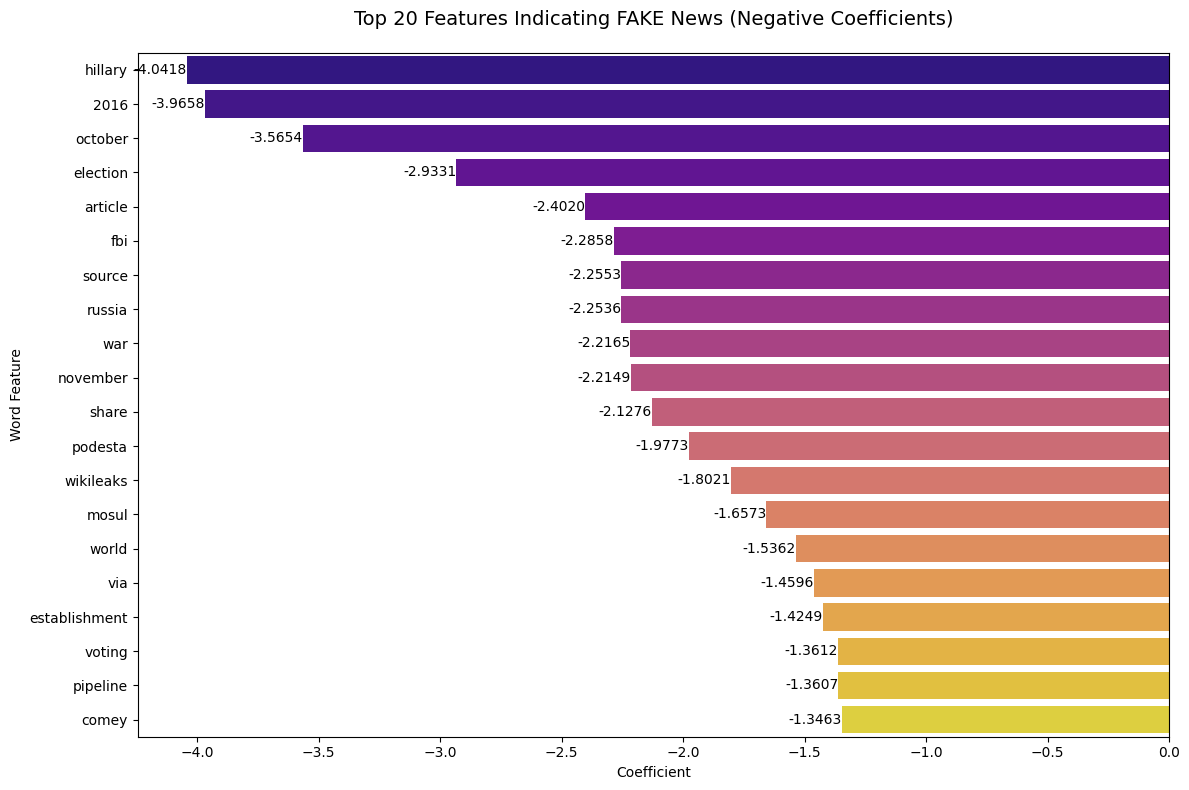


Top 20 Features for FAKE News:
hillary              -4.0418
2016                 -3.9658
october              -3.5654
election             -2.9331
article              -2.4020
fbi                  -2.2858
source               -2.2553
russia               -2.2536
war                  -2.2165
november             -2.2149
share                -2.1276
podesta              -1.9773
wikileaks            -1.8021
mosul                -1.6573
world                -1.5362
via                  -1.4596
establishment        -1.4249
voting               -1.3612
pipeline             -1.3607
comey                -1.3463


In [ ]:
feature_names = vectorizer.get_feature_names_out()

coeffs = tfidf_lr_model.coef_[0]
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coeffs
})

# Sort by coefficient for REAL news (positive coefficients)
top_real_features = feature_importance_df.sort_values(by='coefficient', ascending=False).head(20)

# Sort by coefficient for FAKE news (negative coefficients)
top_fake_features = feature_importance_df.sort_values(by='coefficient', ascending=True).head(20)

# Plotting for REAL News
plt.figure(figsize=(12, 8))
ax_real = sns.barplot(
    x='coefficient',
    y='feature',
    data=top_real_features,
    hue='feature',
    palette='viridis',
    legend=False
)
for i, v in enumerate(top_real_features['coefficient']):
    ax_real.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=10)
plt.title('Top 20 Features Indicating REAL News (Positive Coefficients)', fontsize=14, pad=20)
plt.xlabel('Coefficient')
plt.ylabel('Word Feature')
plt.tight_layout()
plt.show()

print("\nTop 20 Features for REAL News:")
for feature, coeff in zip(top_real_features['feature'], top_real_features['coefficient']):
    print(f"{feature:<20} {coeff:.4f}")

# Plotting for FAKE News
plt.figure(figsize=(12, 8))
ax_fake = sns.barplot(
    x='coefficient',
    y='feature',
    data=top_fake_features,
    hue='feature',
    palette='plasma',
    legend=False
)
for i, v in enumerate(top_fake_features['coefficient']):
    ax_fake.text(v - 0.0005, i, f'{v:.4f}', va='center', ha='right', fontsize=10) # Adjust ha for negative values
plt.title('Top 20 Features Indicating FAKE News (Negative Coefficients)', fontsize=14, pad=20)
plt.xlabel('Coefficient')
plt.ylabel('Word Feature')
plt.tight_layout()
plt.show()

print("\nTop 20 Features for FAKE News:")
for feature, coeff in zip(top_fake_features['feature'], top_fake_features['coefficient']):
    print(f"{feature:<20} {coeff:.4f}")

In [ ]:
!pip install wordcloud

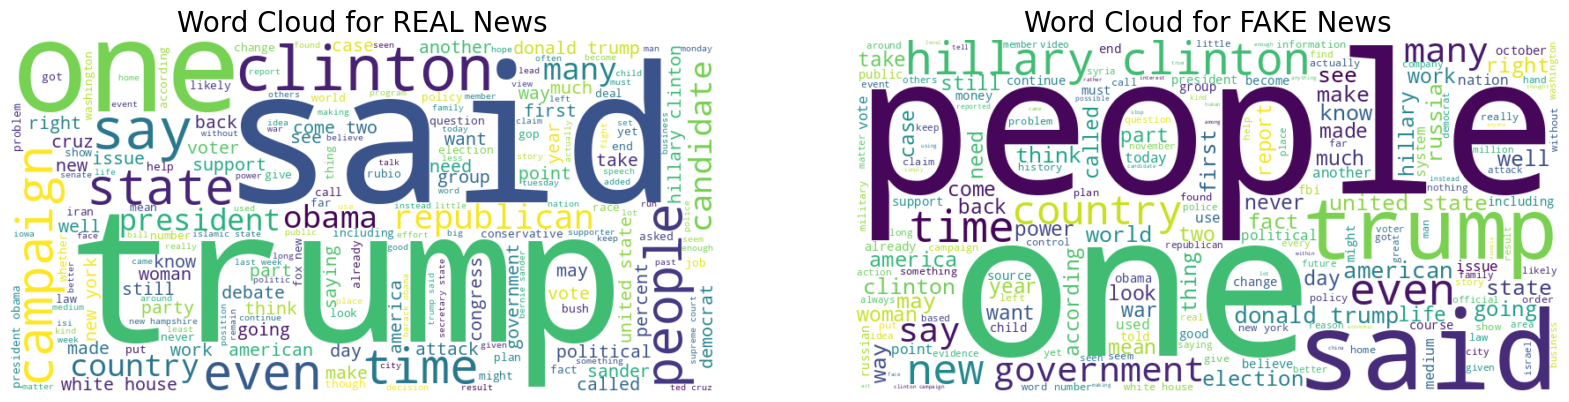

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Filter data for REAL and FAKE news
real_news = df[df['label'] == 'REAL']['processed_data']
fake_news = df[df['label'] == 'FAKE']['processed_data']

all_real_text = " ".join(real_news)
all_fake_text = " ".join(fake_news)

# Generate Word Cloud for REAL news
wordcloud_real = WordCloud(width=800, height=400, background_color='white').generate(all_real_text)

# Generate Word Cloud for FAKE news
wordcloud_fake = WordCloud(width=800, height=400, background_color='white').generate(all_fake_text)

plt.figure(figsize=(20, 10))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.title('Word Cloud for REAL News', fontsize=20)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.title('Word Cloud for FAKE News', fontsize=20)
plt.axis('off')

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_content_train, X_content_test, y_labels_train, y_labels_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("="*50)
print("ERROR ANALYSIS")
print("="*50)

results_df = pd.DataFrame({
    'True_Label': y_test,
    'Predicted_Label': X_test_prediction,
    'Content': X_content_test.values
})

results_df['True_Label_Text'] = results_df['True_Label'].map({0: 'FAKE', 1: 'REAL'})
results_df['Predicted_Label_Text'] = results_df['Predicted_Label'].map({0: 'FAKE', 1: 'REAL'})

misclassified = results_df[results_df['True_Label'] != results_df['Predicted_Label']]
print(f"\nNumber of misclassified samples: {len(misclassified)} ({len(misclassified)/len(y_test)*100:.2f}%) Kishan")

print("\nExamples of misclassified news:")
for i, (idx, row) in enumerate(misclassified.head(5).iterrows()):
    print(f"\nExample {i+1}:")
    print(f"True Label: {row['True_Label_Text']}")
    print(f"Predicted: {row['Predicted_Label_Text']}")
    content_preview = row['Content'][:200] + "..." if len(row['Content']) > 200 else row['Content']
    print(f"Content Preview: {content_preview}")
    print("-" * 50)

ERROR ANALYSIS

Number of misclassified samples: 96 (7.58%) Kishan

Examples of misclassified news:

Example 1:
True Label: REAL
Predicted: FAKE
Content Preview: donald trump going win hillary clinton defeat trump represents trump alliance desire remake world image class representing neoliberal globalization insisted difference starker capitalism today placele...
--------------------------------------------------

Example 2:
True Label: FAKE
Predicted: REAL
Content Preview: clinton add michelle obama cabinet home politics clinton add michelle obama cabinet clinton add michelle obama cabinet share hillary clinton say open making first lady michelle obama member cabinet be...
--------------------------------------------------

Example 3:
True Label: FAKE
Predicted: REAL
Content Preview: kenyan refugee kill worker self kenyan refugee kill worker self others shot hard worker fired job published min ago roanoke refugee kenya killed one former worker wounded three others killed tuesday w...


In [ ]:
def predict_news(text):
    cleaned_text = clean_text(text)
    processed_text = tokenize_and_lemmatize(cleaned_text)

    text_tfidf = vectorizer.transform([processed_text])

    prediction = tfidf_lr_model.predict(text_tfidf)
    probability = tfidf_lr_model.predict_proba(text_tfidf)

    label = le.inverse_transform(prediction)[0]

    return {
        'prediction': label,
        'probability_fake': probability[0][0],
        'probability_real': probability[0][1],
        'is_fake': label == 'FAKE'
    }

print("="*50)
print("TEST PREDICTION")
print("="*50)

test_cases = [
    "Breaking news: Scientists discover new treatment for cancer that shows 95% success rate in trials.",
    "Aliens have landed in New York City and are taking over government buildings, says anonymous source.",
    "The president announced new economic policies aimed at reducing inflation and creating jobs."
]

for i, test_text in enumerate(test_cases):
    result = predict_news(test_text)
    print(f"\nTest Case {i+1}:")
    print(f"Text: {test_text[:100]}...")
    print(f"Prediction: {result['prediction']}")
    print(f"Probability (Fake): {result['probability_fake']:.4f}")
    print(f"Probability (Real): {result['probability_real']:.4f}")

TEST PREDICTION

Test Case 1:
Text: Breaking news: Scientists discover new treatment for cancer that shows 95% success rate in trials....
Prediction: FAKE
Probability (Fake): 0.7958
Probability (Real): 0.2042

Test Case 2:
Text: Aliens have landed in New York City and are taking over government buildings, says anonymous source....
Prediction: FAKE
Probability (Fake): 0.8031
Probability (Real): 0.1969

Test Case 3:
Text: The president announced new economic policies aimed at reducing inflation and creating jobs....
Prediction: FAKE
Probability (Fake): 0.5649
Probability (Real): 0.4351


In [ ]:
print("PERFORMANCE SUMMARY")
print("="*50)

print(f"Dataset Statistics:")
print(f"Total samples: {len(df)}")
print(f"Fake news (label='FAKE'): {len(df[df['label'] == 'FAKE'])}")
print(f"Real news (label='REAL'): {len(df[df['label'] == 'REAL'])}")

print(f"\nModel Performance Summary:")
print(f"Overall Accuracy: {test_accuracy:.4f}")

from sklearn.metrics import precision_score, recall_score, f1_score
print(f"Precision (Real=1): {precision_score(y_test, X_test_prediction, pos_label=1):.4f}")
print(f"Recall (Real=1): {recall_score(y_test, X_test_prediction, pos_label=1):.4f}")
print(f"F1-Score (Real=1): {f1_score(y_test, X_test_prediction, pos_label=1):.4f}")

PERFORMANCE SUMMARY
Dataset Statistics:
Total samples: 6335
Fake news (label='FAKE'): 3164
Real news (label='REAL'): 3171

Model Performance Summary:
Overall Accuracy: 0.9242
Precision (Real=1): 0.9529
Recall (Real=1): 0.8927
F1-Score (Real=1): 0.9218


In [ ]:
import joblib

logreg_model_to_save = tfidf_lr_model
pred_lr = X_test_prediction

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acc_lr = accuracy_score(y_test, pred_lr)
prec_lr = precision_score(y_test, pred_lr, pos_label=1)
rec_lr = recall_score(y_test, pred_lr, pos_label=1)
f1_lr = f1_score(y_test, pred_lr, pos_label=1)

print("=== Logistic Regression Performance ===")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

joblib.dump(logreg_model_to_save, "logreg_news_classifier.joblib")
print("Model Logistic Regression berhasil disimpan sebagai logreg_news_classifier.joblib")

joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
print("TF-IDF Vectorizer berhasil disimpan sebagai tfidf_vectorizer.joblib")

joblib.dump(le, "label_encoder.joblib")
print("LabelEncoder berhasil disimpan sebagai label_encoder.joblib")

=== Logistic Regression Performance ===
Accuracy : 0.9242
Precision: 0.9529
Recall   : 0.8927
F1-Score : 0.9218
Model Logistic Regression berhasil disimpan sebagai logreg_news_classifier.joblib
TF-IDF Vectorizer berhasil disimpan sebagai tfidf_vectorizer.joblib
LabelEncoder berhasil disimpan sebagai label_encoder.joblib
